In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import cv2


In [4]:
img = cv2.imread("images/01_HSRM.jpg")

In [5]:
type(img), img.dtype, img.shape

(numpy.ndarray, dtype('uint8'), (785, 1200, 3))

In [6]:
img[123,123]

array([208, 192, 185], dtype=uint8)

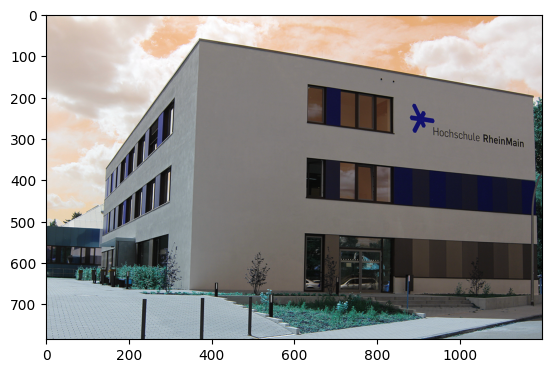

In [7]:
plt.imshow(img)
plt.show()

# Kapitel zu salt and pepper noise

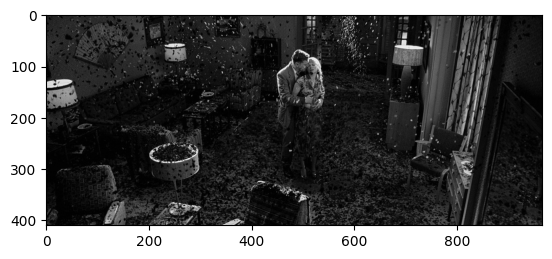

In [8]:
img = cv2.imread('images/shutter_island_colors.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap='grey')


Roberts Prewitt Sobel Edge Operations

In [9]:
def to_u8(z):
    z = z - z.min()
    z = z / z.max() * 255
    return z.astype(np.uint8)

In [10]:
# Roberts
HR1 = np.array([[ 0, 1], [-1, 0]], dtype=np.float32)
HR2 = np.array([[-1, 0], [ 0, 1]], dtype=np.float32)
# Prewitt
HPx = np.array([[1], [1], [1]]) * np.array([-1, 0, 1])
HPy = HPx.T
# Sobel
HSx = np.array([[1], [2], [1]]) * np.array([-1, 0, 1])
HSy = HSx.T

In [11]:
IR1, IR2, IPx, IPy, ISx, ISy = [
cv2.filter2D(img, cv2.CV_32F, k)/np.sum(np.abs(k))
for k in [HR1, HR2, HPx, HPy, HSx, HSy]]

mag_roberts = np.sqrt(IR1**2 + IR2**2)
mag_prewitt = np.sqrt(IPx**2 + IPy**2)
mag_sobel = np.sqrt(ISx**2 + ISy**2)

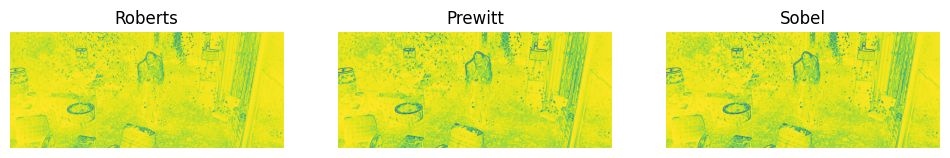

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1);
plt.title('Roberts'); plt.imshow(255-to_u8(mag_roberts)); plt.axis("off")
plt.subplot(1, 3, 2);
plt.title('Prewitt'); plt.imshow(255-to_u8(mag_prewitt)); plt.axis("off")
plt.subplot(1, 3, 3);
plt.title('Sobel'); plt.imshow(255-to_u8(mag_sobel)); plt.axis("off")
plt.show()

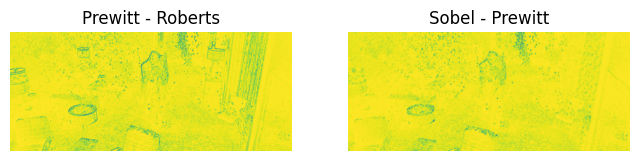

In [13]:
dRP = np.abs(mag_prewitt - mag_roberts)
dPS = np.abs(mag_sobel - mag_prewitt)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title('Prewitt - Roberts'); plt.imshow(255-to_u8(dRP)); plt.axis("off")
plt.subplot(1, 2, 2)
plt.title('Sobel - Prewitt'); plt.imshow(255-to_u8(dPS)); plt.axis("off")
plt.show()

In [14]:
img = cv2.imread('images/test/Bart_Simpson.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ... Edge Detection usw.m

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
# img = cv2.imread('images/test/Trump_Executive_Order.avif', cv2.IMREAD_GRAYSCALE)


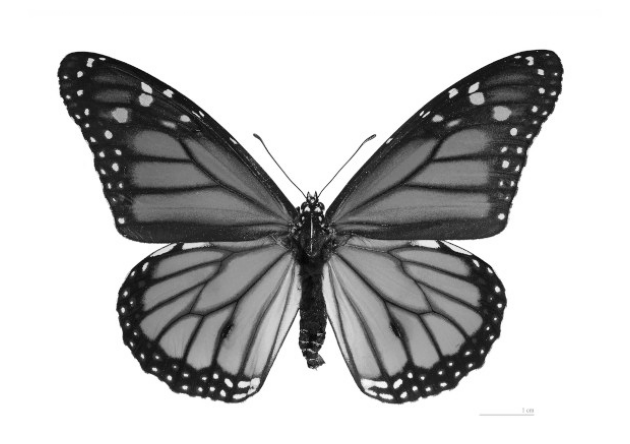

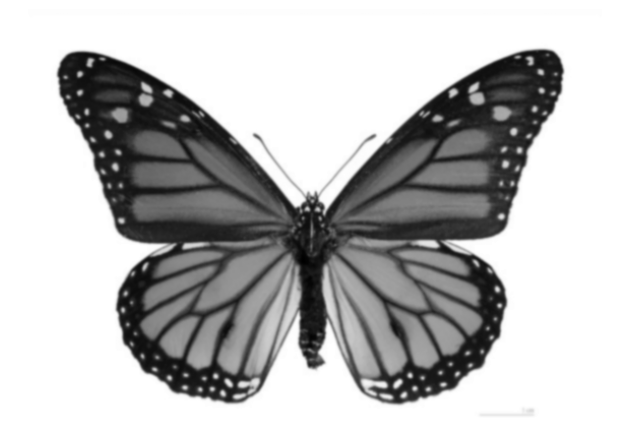

In [ ]:
img = cv2.imread('images/test/Butterfly.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
sigma = 1
img_blur = cv2.GaussianBlur(img, (0,0), sigma)
plt.imshow(to_u8(img_blur), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()

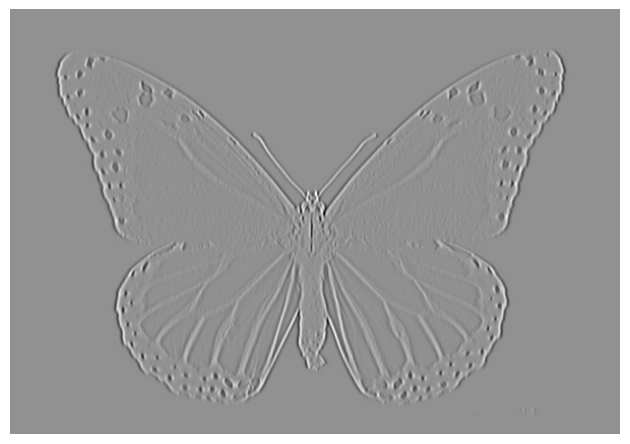

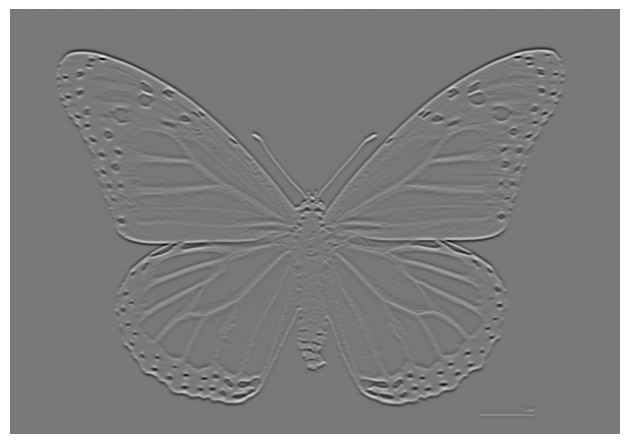

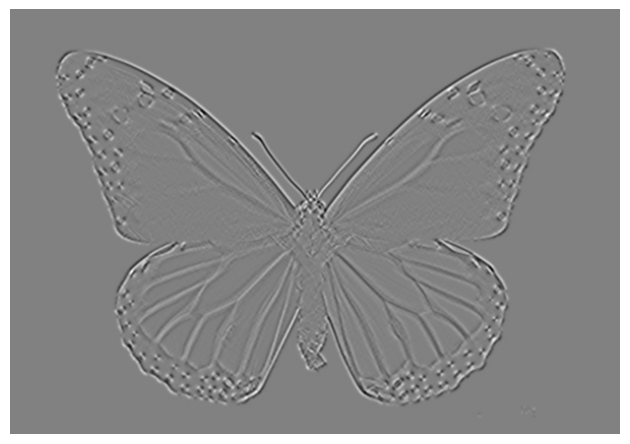

In [ ]:
Ixx = cv2.Sobel(img_blur, cv2.CV_32F, 2, 0, ksize=3)
Iyy = cv2.Sobel(img_blur, cv2.CV_32F, 0, 2, ksize=3)
Ixy = cv2.Sobel(img_blur, cv2.CV_32F, 1, 1, ksize=3)

plt.imshow(to_u8(Ixx), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(to_u8(Iyy), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(to_u8(Ixy), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()

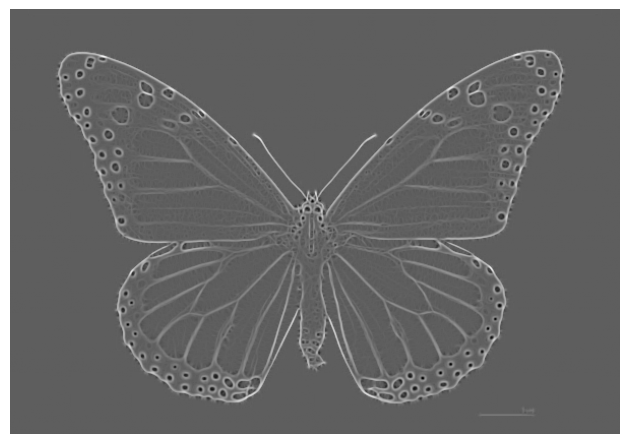

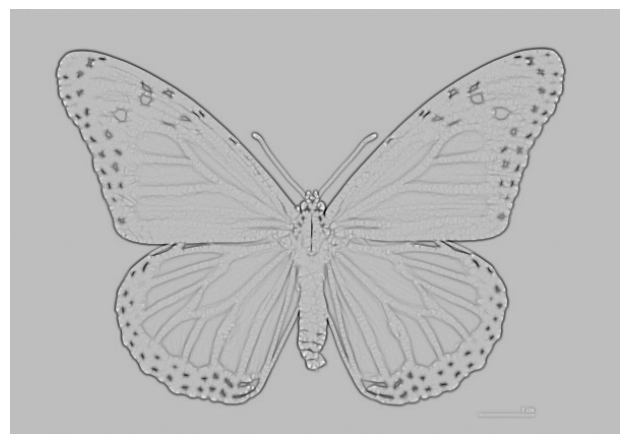

In [ ]:
tmp = np.sqrt((Ixx - Iyy)**2 + 4*Ixy**2)
lambda1 = 0.5 * (Ixx + Iyy + tmp)
lambda2 = 0.5 * (Ixx + Iyy - tmp)
plt.imshow(to_u8(lambda1), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(to_u8(lambda2), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()

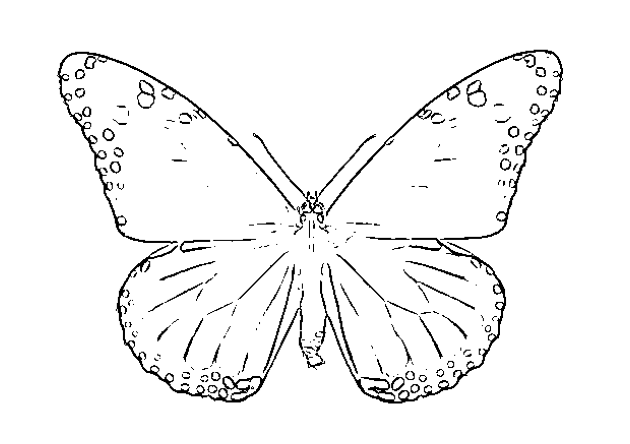

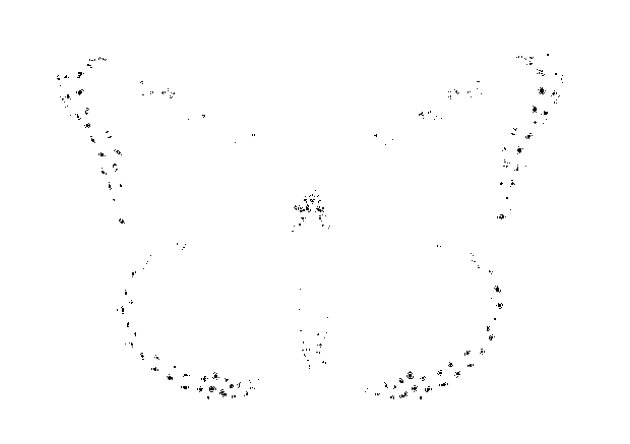

In [ ]:
abs1 = np.abs(lambda1) # the response
abs2 = np.abs(lambda2) # distinguish between lines and blobs
# thresholds
thr1 = 0.2 * np.max(abs1)
thr2 = 0.2 * np.max(abs2)
lines = (abs1 > thr1) & (abs2 < thr1)
blobs = (abs1 > thr1) & (abs2 > thr2)
plt.imshow(255-to_u8(lines.astype(int)), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()
plt.imshow(255-to_u8(blobs.astype(int)), cmap='gray'); plt.axis("off"); plt.tight_layout(); plt.show()

In [18]:
def to_u8(z):
    z = z - z.min()
    z = z / (z.max() + 1e-6) * 255
    return z.astype(np.uint8)

def imshow(img, title=None, cmap='gray', colorbar=False):
    plt.imshow(img, cmap=cmap); plt.axis("off"); plt.title(title)
    if colorbar: plt.colorbar()
    plt.show()

smoothing notwendig cv2.Line_AA für standardmäßiges gutes antialiasing

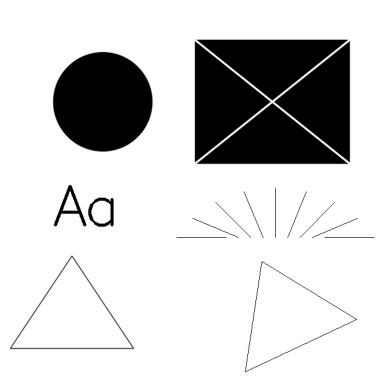

In [33]:
img = np.full((600, 600), 255, np.uint8)
cv2.circle(img, (150, 150), 80, 0, -1, lineType=cv2.LINE_AA)
cv2.fillPoly(img, [np.int32([(300, 50), (550, 50), (550, 250), (300, 250)])], 0, lineType=cv2.LINE_AA)
cv2.line(img, (300, 50), (550, 250), 255, 2, lineType=cv2.LINE_AA)
cv2.line(img, (550, 50), (300, 250), 255, 2, lineType=cv2.LINE_AA)

pivot = (350, 370)
for a in np.linspace(0, 180, 9):
    t = np.deg2rad(180 - a)
    cv2.line(img, pivot, (int(pivot[0]+80*np.cos(t)), int(pivot[1]-80*np.sin(t))), 0, 1)
    pivot = (pivot[0] + 20, pivot[1])
    
cv2.polylines(img, [np.int32([[100, 400], [200, 550], [0, 550]])], True, 0, 1, lineType=cv2.LINE_AA)

M = cv2.getRotationMatrix2D((450, 500), 25, 1.0)
rotated = cv2.transform(np.array([[[450, 400], [550, 550], [350, 550]]], np.int32), M)
cv2.polylines(img, [np.int32(rotated)], True, 0, 1)

cv2.putText(img, 'A', (70, 350), cv2.FONT_HERSHEY_SIMPLEX, 3, 0, 4)
cv2.putText(img, 'a', (120, 350), cv2.FONT_HERSHEY_SIMPLEX, 3, 0, 4)

imshow(img)

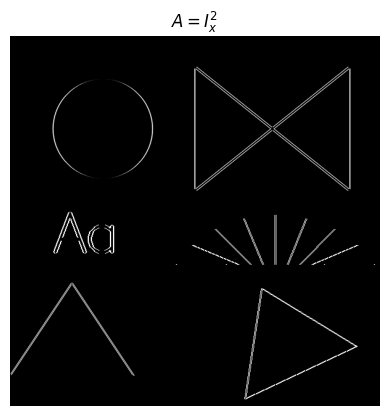

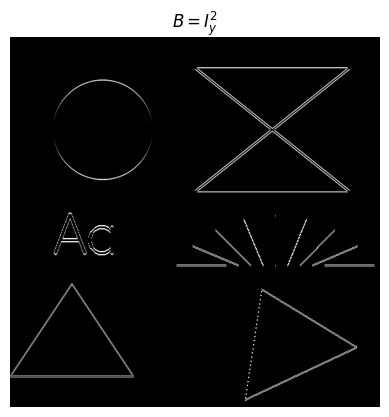

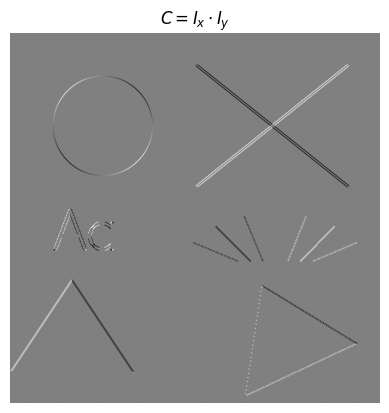

In [34]:
Hx = np.array([[-0.5, 0.0, 0.5]]) # 1x3
Hy = Hx.T
Ix = cv2.filter2D(img, cv2.CV_32F, Hx)
Iy = cv2.filter2D(img, cv2.CV_32F, Hy)

A = Ix**2
B = Iy**2
C = Ix*Iy

imshow(A, "$A=I_x^2$")
imshow(B, "$B=I_y^2$")
imshow(C, "$C=I_x \cdot I_y$")

In [35]:
sigma = 1.275
ksize = int(6 * sigma + 1) # standard rule of thumb for kernel size
if ksize % 2 == 0:
    ksize += 1 # must be odd for OpenCV
    
Abar = cv2.GaussianBlur(A, (ksize, ksize), sigmaX=sigma)
Bbar = cv2.GaussianBlur(B, (ksize, ksize), sigmaX=sigma)
Cbar = cv2.GaussianBlur(C, (ksize, ksize), sigmaX=sigma)

Daumenregel 6xSigma + 1, wenn gerade anzahl dann noch 1ns mehr. Größere Ecken würde bedeuten größeres Sigma

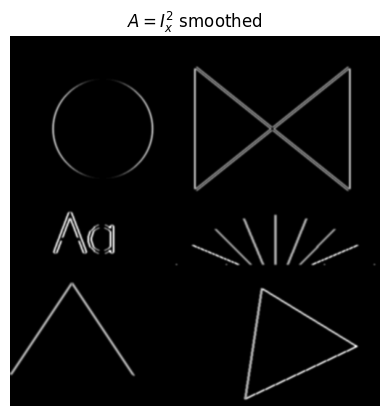

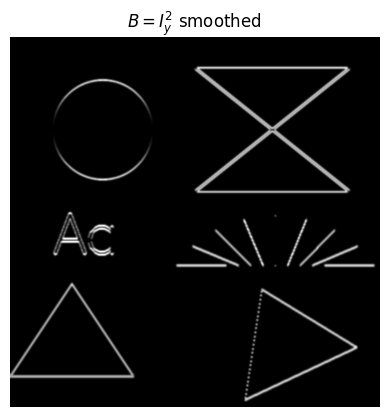

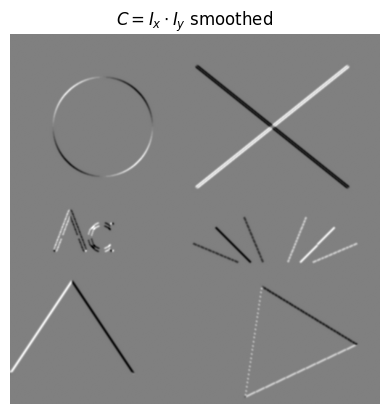

In [36]:
imshow(Abar, "$A=I_x^2$ smoothed")
imshow(Bbar, "$B=I_y^2$ smoothed")
imshow(Cbar, "$C=I_x \cdot I_y$ smoothed")

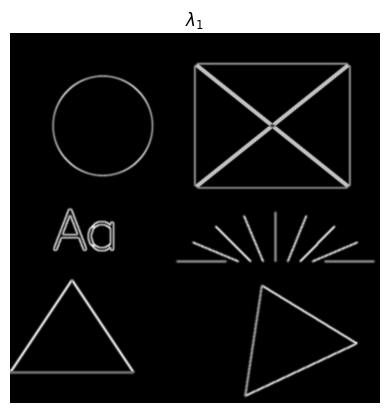

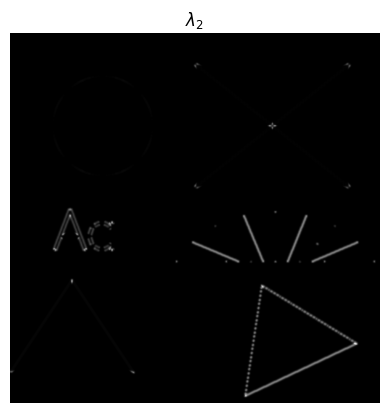

In [37]:
trace = Abar + Bbar
diff = Abar - Bbar
sqrt_term = np.sqrt(np.maximum(0.0, diff*diff + 4.0 * (Cbar*Cbar)))
lambda1 = 0.5 * (trace + sqrt_term)
lambda2 = 0.5 * (trace - sqrt_term)

imshow(lambda1, "$\lambda_1$")
imshow(lambda2, "$\lambda_2$")

Lambda 1 schlägt aus überall wenn linie ist. Und Lambda 2 schlägt meistens aus bzw. größer / mehr bei Ecken. Man kann auch sobel oprator nehmen um zu smoothen ohne antialiasing

In [38]:
alpha = 0.095 # try 0.04–0.10
detM = Abar * Bbar - Cbar * Cbar
traceM = Abar + Bbar

QH = detM - alpha * (traceM ** 2)
QS = lambda2.copy()
QM = detM / np.maximum(traceM, 1e-12) # division von 0 vermeiden deswegen 1e-12 setzen

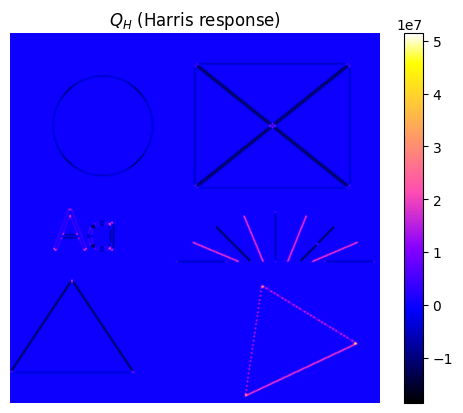

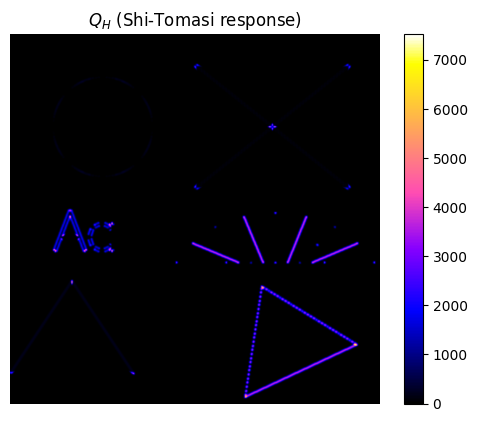

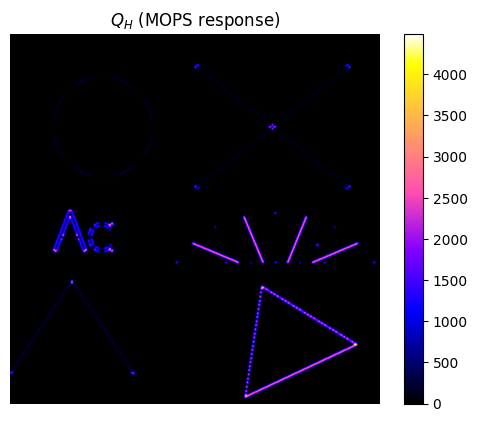

In [39]:
imshow(QH, "$Q_H$ (Harris response)", "gnuplot2", True)
imshow(QS, "$Q_H$ (Shi-Tomasi response)", "gnuplot2", True)
imshow(QM, "$Q_H$ (MOPS response)", "gnuplot2", True)

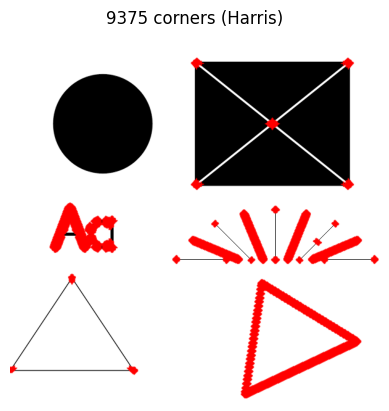

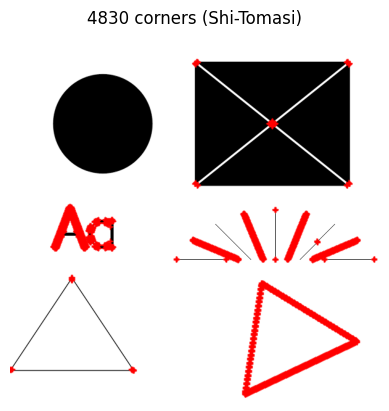

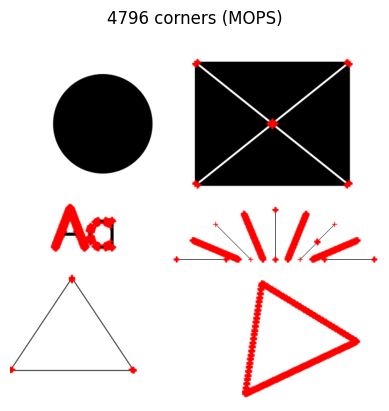

In [40]:
th_H = 20000 # Harris
th_S = 1250 # Shi-Tomasi
th_M = 1000 # MOPS

corners_H = QH > th_H
corners_S = QS > th_S
corners_M = QM > th_M

def addMarkers(img, corners):
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # convert to color image
    ys, xs = np.where(corners)
    for (x, y) in zip(xs, ys):
        cv2.drawMarker(overlay, (int(x), int(y)),
            color=(255, 0, 0), # red
            markerType=cv2.MARKER_CROSS, markerSize=8,
            thickness=1, line_type=cv2.LINE_AA)
    
    return overlay


for corners, name in [(corners_H, 'Harris'), (corners_S, 'Shi-Tomasi'), (corners_M, 'MOPS')]:
    imshow(addMarkers(img, corners), f"{np.sum(corners)} corners ({name})")

In [41]:
QH_max = cv2.dilate(QH, np.ones((3,3), np.uint))
QS_max = cv2.dilate(QS, np.ones((3,3), np.uint))
QM_max = cv2.dilate(QM, np.ones((3,3), np.uint))

corners_H = (QH > th_H) & (QH_max == QH)
corners_S = (QS > th_S) & (QH_max == QS)
corners_M = (QM > th_M) & (QH_max == QM)

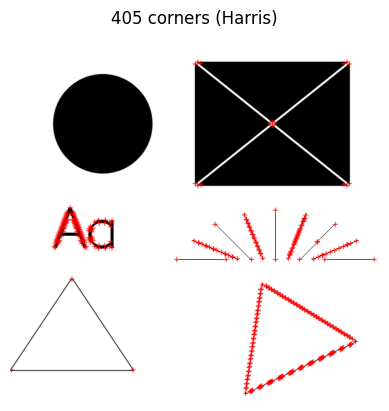

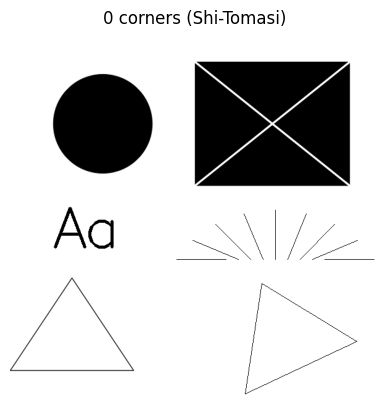

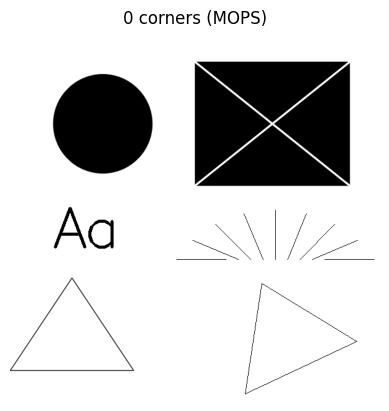

In [42]:
# Visualisieren:
for corners, name in [(corners_H, 'Harris'), (corners_S, 'Shi-Tomasi'), (corners_M, 'MOPS')]:
    imshow(addMarkers(img, corners), f"{np.sum(corners)} corners ({name})")

### Example bad edges

In [1]:
# wegen platzmangel kann ich die Bilder nicht richtig importieren / laden
img = cv2.imread()

NameError: name 'cv2' is not defined

In [ ]:
Ix = np.stack([IxR, IxG, IxB], axis=2) # HxWx3
Ix = np.stack([IyR, IyG, IyB], axis=2) # HyWy3

gxx = np.sum (Ix * Ix, axis=2) # structure matrix compnents
gyy = np.sum (Iy * Iy, axis=2) 
gxy = np.sum (Ix * Iy, axis=2) 

tr = gxx + gyy


# Geometric Operations

In [ ]:
img = cv2.imread('images/')

# Motion Detektion

reading Video Files:

Dauer des Videos: 306.1333333333333Sekunden


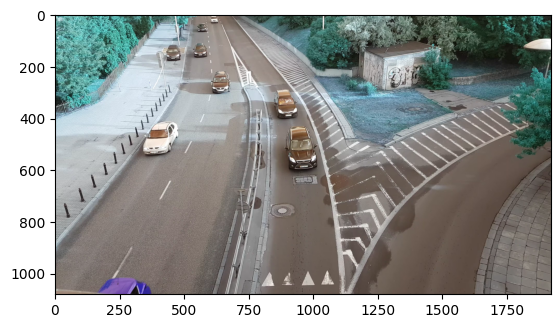

In [6]:
videofile = 'images/test/Traffic.mp4'

cap = cv2.VideoCapture(videofile) # open video file
fps = cap.get(cv2.CAP_PROP_FPS) # get frames per second
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # get number of frames

print ('Dauer des Videos: ' + str(frame_count/fps) + 'Sekunden')

ret, frame = cap.read() # returns (bool, BGR)
plt.imshow(frame)

# Hintergrund berechnen

In [7]:
frames = []

for _ in range(int(10*fps)): # Die Frames der ersten 10 Sekunden lesen
    ret, frame = cap.read()
    frames += [frame]
    
len(frames)

300

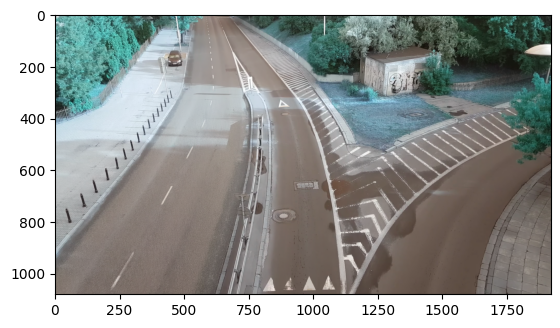

In [8]:
background = np.median(np.stack(frames, axis=0), axis=0).astype(np.uint8) # median intensity

plt.imshow(background)

# Foreground Extratcion

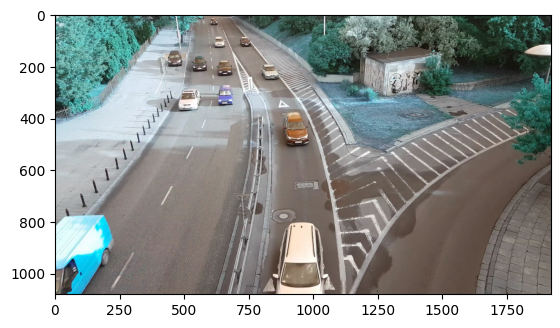

In [10]:
plt.imshow(frame)

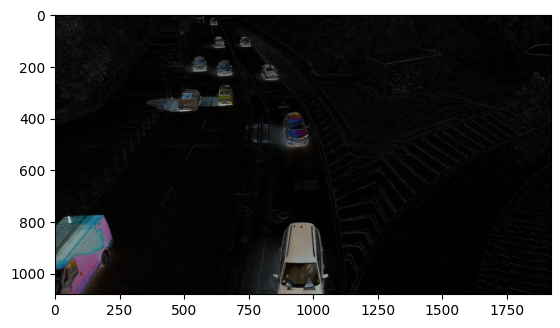

In [11]:
fg = cv2.absdiff(frame, background)
plt.imshow(fg)

# Frame Aligment

In [ ]:
def align_frame(frame, ref): # nicht ganz sicher
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    ref_gray = cv2.cvtColor(ref, cv2.COLOR_RGB2GRAY)
    warp_matrix = np.eye(2, 3, dtype=np.float32) # identity transform matrix
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 50, 1e-4) # last two: iterations, eps
    try:
        cv2.findTransformECC(ref_gray, frame_gray, warp_matrix, cv2.MOTION_AFFINE, criteria)
    except cv2.error:
        return frame
    h, w, _ = ref.shape
    aligned = ref.copy()
    cv2.warpAffine(frame, warp_matrix, (w, h), dst=aligned,
    flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
    borderMode=cv2.BORDER_TRANSPARENT) # we're using background to fill the gaps
    


# Calculate Distance

In [ ]:
# fg = np.max(fg, axis=2)
# fg = np.sqrt(np.sum(diff*diff, axis=2)) # L2 Norm
dist = np.sum(diff, axis=2) # L1 Norm
_, fg = cv2.theshold(dist, 70, 255, cv2.THRESH_BINARY)

plt.imshow(dist)
plt.imshow(fg)

NameError: name 'diff' is not defined